# Homework 3 part 1

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

from src.runner import run_all

data_path = "data/datahw3.npz"
est_configs = [2, 10, 50, 75, 100]
use_tqdm = True

In [11]:
results = run_all(data_path, est_configs, use_tqdm)
# Build tidy rows from the results dict
mapping = {
    'bag_ds1': ('Bagging', 'D1'),
    'bag_ds2': ('Bagging', 'D2'),
    'boost_ds1': ('Boosting', 'D1'),
    'boost_ds2': ('Boosting', 'D2'),
}
dfs = {}
est = 'number of estimators'
zol = 'zero-one loss'
auc = 'roc area under curve'
for key, vals in results.items():
    rows = []
    method, dataset = mapping.get(key, (key, ''))
    for x, y, z in vals:
        rows.append({
            est: int(x),
            zol: float(y),
            auc: float(z)})
    dfs[key] = pd.DataFrame(rows)

df_bag1 = dfs['bag_ds1'].sort_values(est).set_index(est)
df_boost1 = dfs['boost_ds1'].sort_values(est).set_index(est)
df_bag2 = dfs['bag_ds2'].sort_values(est).set_index(est)
df_boost2 = dfs['boost_ds2'].sort_values(est).set_index(est)

bagging n_estimators:   0%|          | 0/5 [00:00<?, ?it/s]

bagging n_estimators:   0%|          | 0/5 [00:00<?, ?it/s]

boosting n_estimators:   0%|          | 0/5 [00:00<?, ?it/s]

boosting n_estimators:   0%|          | 0/5 [00:00<?, ?it/s]

## Bagging Ensemble Classifiers

### Dataset 1

In [12]:
df_bag1


,zero-one loss,roc area under curve
number of estimators,,
2,0.1,0.964286
10,0.3,0.952381
50,0.3,0.952381
75,0.3,0.940476
100,0.3,0.940476


### Dataset 2

In [13]:
df_bag2

,zero-one loss,roc area under curve
number of estimators,,
2,0.35,0.606061
10,0.35,0.606061
50,0.35,0.616162
75,0.35,0.606061
100,0.40,0.616162


## Boosting Ensemble Classifiers

### Dataset 1

In [14]:
df_boost1

,zero-one loss,roc area under curve
number of estimators,,
2,0.30,0.857143
10,0.40,0.648810
50,0.20,0.833333
75,0.25,0.750000
100,0.30,0.714286


### Dataset 2

In [15]:
df_boost2

,zero-one loss,roc area under curve
number of estimators,,
2,0.2,0.828283
10,0.3,0.838384
50,0.4,0.757576
75,0.3,0.777778
100,0.4,0.717172


## Visualization

### Compare ROC AUC

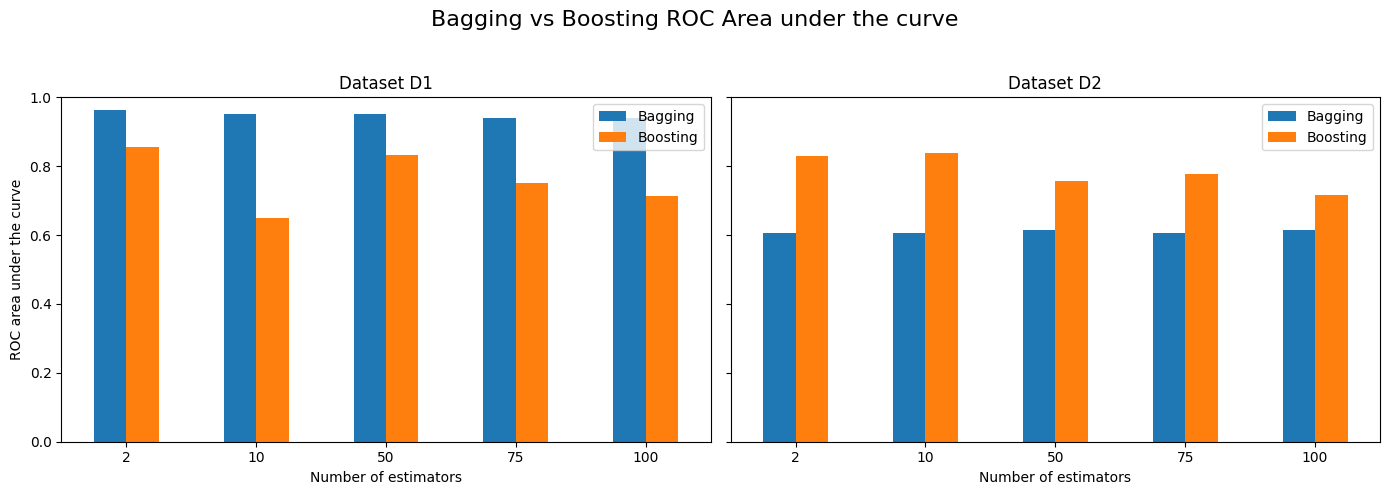

In [16]:
# compare AUC for bagging vs boosting: show D1 and D2 side-by-side
# build pivoted DataFrames for each dataset
plot_df1 = pd.DataFrame({'Bagging': df_bag1[auc], 'Boosting': df_boost1[auc]})
plot_df2 = pd.DataFrame({'Bagging': df_bag2[auc], 'Boosting': df_boost2[auc]})

# create a single figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_df1.plot(kind='bar', ax=axes[0])
axes[0].set_xlabel('Number of estimators')
axes[0].set_ylabel('ROC area under the curve')
axes[0].set_title('Dataset D1')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 1)

plot_df2.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Number of estimators')
axes[1].set_title('Dataset D2')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 1)

fig.suptitle('Bagging vs Boosting ROC Area under the curve', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Compare Zero-One Loss

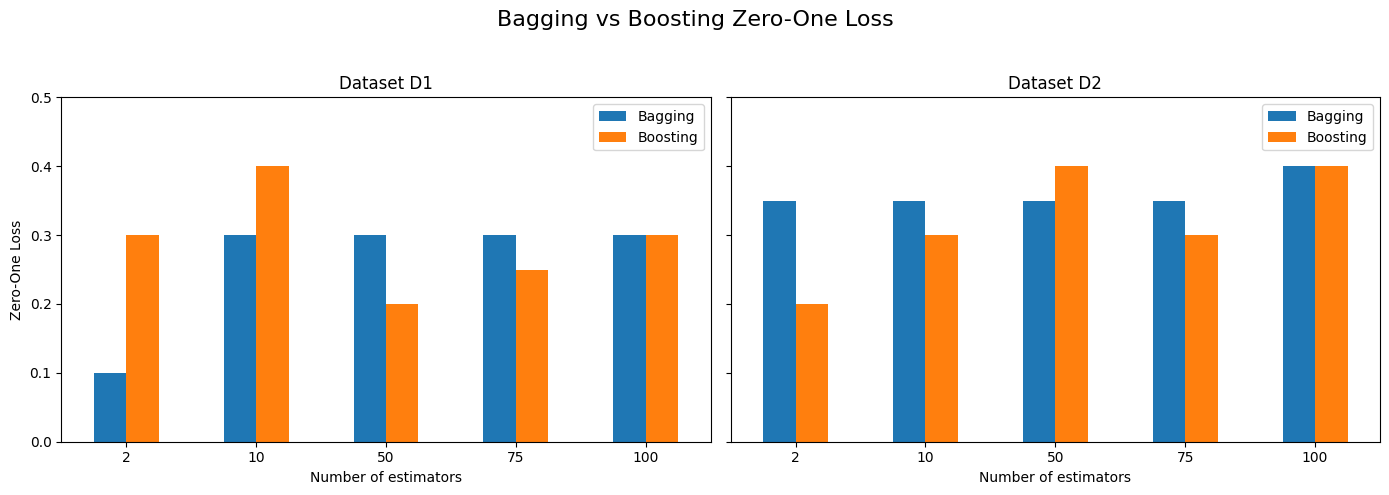

In [17]:
# compare AUC for bagging vs boosting: show D1 and D2 side-by-side
# build pivoted DataFrames for each dataset
plot_df1 = pd.DataFrame({'Bagging': df_bag1[zol], 'Boosting': df_boost1[zol]})
plot_df2 = pd.DataFrame({'Bagging': df_bag2[zol], 'Boosting': df_boost2[zol]})

# create a single figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
plot_df1.plot(kind='bar', ax=axes[0])
axes[0].set_xlabel('Number of estimators')
axes[0].set_ylabel('Zero-One Loss')
axes[0].set_title('Dataset D1')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_ylim(0, 0.5)

plot_df2.plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Number of estimators')
axes[1].set_title('Dataset D2')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 0.5)

fig.suptitle('Bagging vs Boosting Zero-One Loss', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()